# Working with Spin objects directly

`SpinPlots` makes it easy to create plots with a few lines of code using the `.plot()` method, advanced users might want more control over data visualization. This tutorial will show you how to work directly with `Spin` and `SpinCollection` objects to access raw data, process it, and create custom plots.

## Spin and SpinCollection objects

SpinPlots provides two main classes for handling NMR data:

1. `Spin`: Represents a single NMR dataset
2. `SpinCollection`: Is a collection of `Spin` objects

### Working with Spin objects

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from spinplots.io import read_nmr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# 1D data
glycine = read_nmr("../../data/1D/glycine/pdata/1", provider="bruker")

print(f"Object type: {type(glycine).__name__}")
print(f"Dimensions: {glycine.ndim}D")
print(f"Provider: {glycine.provider}")
print(f"Path to file: {glycine.spectrum['path']}")

print("\nAvailable keys")
for key in glycine.spectrum.keys():
    print(f"- {key}")

Object type: Spin
Dimensions: 1D
Provider: bruker
Path to file: ../../data/1D/glycine/pdata/1

Available keys
- path
- metadata
- ndim
- data
- norm_max
- norm_scans
- projections
- ppm_scale
- hz_scale
- nuclei


In [3]:
# Load a 2D spectrum
spectrum_2d = read_nmr("../../data/2D/16/pdata/1", provider="bruker")

print(f"Type: {type(spectrum_2d).__name__}")
print(f"Dimensions: {spectrum_2d.ndim}D")
print(f"Provider: {spectrum_2d.provider}")
print(f"Path to file: {spectrum_2d.spectrum['path']}")

print("\nAvailable keys")
for key in spectrum_2d.spectrum.keys():
    print(f"- {key}")

Type: Spin
Dimensions: 2D
Provider: bruker
Path to file: ../../data/2D/16/pdata/1

Available keys
- path
- metadata
- ndim
- data
- norm_max
- norm_scans
- projections
- ppm_scale
- hz_scale
- nuclei


### Working with SpinCollection

A `SpinCollection` behaves like a dictionary of `Spin` objects, where each spectrum can be accessed by its tag:

In [4]:
# Load multiple spectra into a collection
collection = read_nmr(
    ["../../data/1D/glycine/pdata/1", "../../data/1D/alanine/pdata/1"], 
    provider="bruker",
    tags=["Glycine", "Alanine"]  # Optional custom tags
)

print(f"Type: {type(collection).__name__}")
print(f"Dimensions: {collection.ndim}D")
print(f"Provider: {collection.provider}")
print(f"Path to file 1: {collection[0].spectrum['path']}")
print(f"Path to file 2: {collection[1].spectrum['path']}")

print("\nKeys file 1")
for key in collection[0].spectrum.keys():
    print(f"- {key}")

print("\nKeys file 2")
for key in collection[1].spectrum.keys():
    print(f"- {key}")



Type: SpinCollection
Dimensions: 1D
Provider: bruker
Path to file 1: ../../data/1D/glycine/pdata/1
Path to file 2: ../../data/1D/alanine/pdata/1

Keys file 1
- path
- metadata
- ndim
- data
- norm_max
- norm_scans
- projections
- ppm_scale
- hz_scale
- nuclei

Keys file 2
- path
- metadata
- ndim
- data
- norm_max
- norm_scans
- projections
- ppm_scale
- hz_scale
- nuclei


In [5]:
collection = read_nmr(
    ["../../data/1D/glycine/pdata/1", "../../data/1D/alanine/pdata/1"], 
    provider="bruker",
    tags=["Glycine", "Alanine"]  # Add custom tag
)

glycine_spin = collection["Glycine"]
alanine_spin = collection["Alanine"]

print(f"Glycine Spin object: {glycine_spin}")
print(f"Alanine Spin object: {alanine_spin}")

# Can also be accessed by index
first_spin = collection[0]
print(f"\nFirst Spin in collection: {first_spin}")

# Get all tags
all_tags = list(collection.spins.keys())
print(f"\nAvailable spectra: {all_tags}")

Glycine Spin object: Spin(tag=Glycine, ndim=1, provider='bruker', path=../../data/1D/glycine/pdata/1)
Alanine Spin object: Spin(tag=Alanine, ndim=1, provider='bruker', path=../../data/1D/alanine/pdata/1)

First Spin in collection: Spin(tag=Glycine, ndim=1, provider='bruker', path=../../data/1D/glycine/pdata/1)

Available spectra: ['Glycine', 'Alanine']


`Spin` objects can be easily added or romoved from a `SpinCollection` with:

In [6]:
tyrosine = read_nmr("../../data/1D/tyrosine/pdata/1", provider="bruker")
tyrosine.tag = "Tyrosine"
collection.append(tyrosine)

print(f"Collection sized after adding: {collection.size}")
print(f"Updated tags: {list(collection.spins.keys())}\n")

collection.remove("Alanine")
print(f"Collection size after removal: {collection.size}")
print(f"Remaining tags: {list(collection.spins.keys())}")

Collection sized after adding: 3
Updated tags: ['Glycine', 'Alanine', 'Tyrosine']

Collection size after removal: 2
Remaining tags: ['Glycine', 'Tyrosine']


## Create plots from Spin objects

The `Spin` object contains all information necessary to make a NMR plot

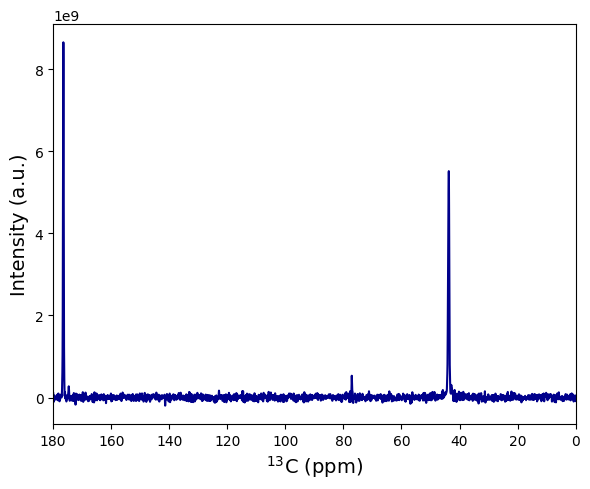

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

# Load glycine spectrum
glycine = read_nmr("../../data/1D/glycine/pdata/1", provider="bruker")
ppm = glycine.spectrum["ppm_scale"]
data = glycine.spectrum["data"]
nuclei = glycine.spectrum["nuclei"]

# Extract the number and nucleus from the nuclei string
number = "".join(filter(str.isdigit, nuclei))
nucleus = "".join(filter(str.isalpha, nuclei))

ax.plot(ppm, data, linewidth=1.5, color='darkblue')
ax.set_xlabel(f"$^{{{number}}}${nucleus} (ppm)", fontsize=14)
ax.set_ylabel("Intensity (a.u.)", fontsize=14)
ax.set_xlim(180, 0)
plt.tight_layout()
plt.show()

You can also use all the data in `SpinCollection` objects to plot the data as you wish

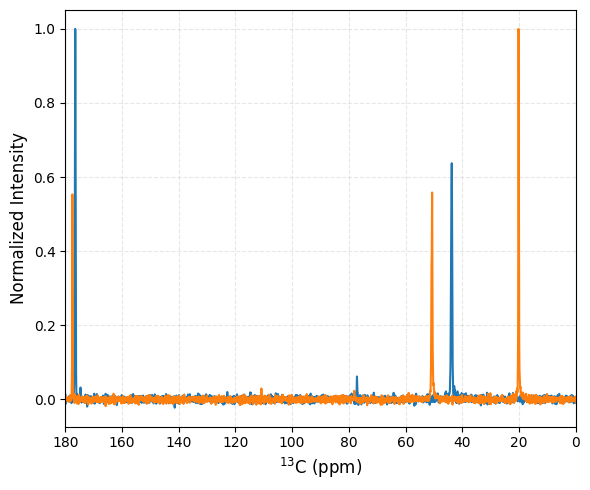

In [8]:
collection = read_nmr(
    ["../../data/1D/glycine/pdata/1", "../../data/1D/alanine/pdata/1"], 
    provider="bruker",
    tags=["Glycine", "Alanine"]  # Add custom tag
)

fig, ax = plt.subplots(figsize=(6, 5))

colors = ['#1f77b4', '#ff7f0e']

for i, (tag, spin) in enumerate(collection):
    ppm = spin.spectrum["ppm_scale"]
    data = spin.spectrum["norm_max"]  # Use normalized data by maximum intensity
    color = colors[i % len(colors)]
    
    ax.plot(ppm, data, linewidth=1.5, label=tag, color=color)

ax.set_xlabel("$^{13}$C (ppm)", fontsize=12)
ax.set_ylabel("Normalized Intensity", fontsize=12)
ax.set_xlim(180, 0)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

`Spin` and `SpinCollection` objects from 2D spectra can also be used to plot the spectra, with or without projections.

Text(0, 0.5, '$^{13}$C (ppm)')

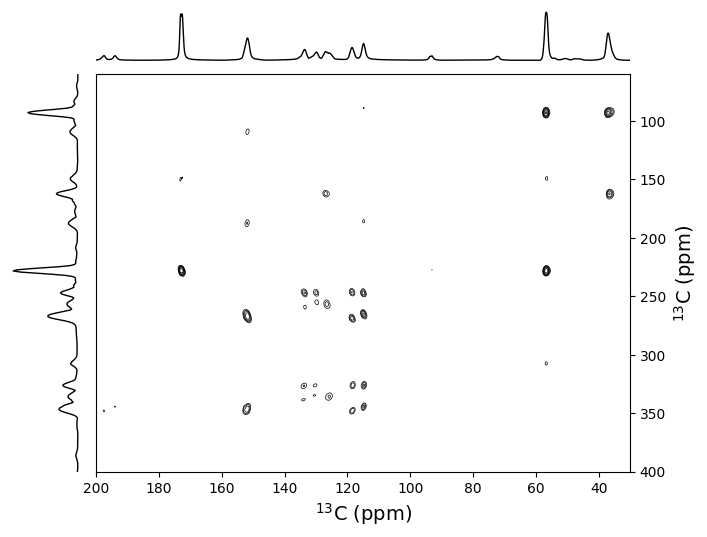

In [9]:
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 2,
                      width_ratios=[0.8, 6],
                      height_ratios=[0.8, 6],
                      wspace=0.05, hspace=0.05)

ax_main = fig.add_subplot(gs[1, 1])  # Main 2D spectrum
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)  # Top projection (F2)
ax_left = fig.add_subplot(gs[1, 0], sharey=ax_main)  # Left projection (F1)

spectrum_2d = read_nmr("../../data/2D/16/pdata/1", provider="bruker")
data_2d = spectrum_2d.spectrum["data"]
ppm_f1 = spectrum_2d.spectrum["ppm_scale"][0]
ppm_f2 = spectrum_2d.spectrum["ppm_scale"][1]
proj_f1 = spectrum_2d.spectrum["projections"]["f1"]['F1 projection']
proj_f2 = spectrum_2d.spectrum["projections"]["f2"]['F2 projection']

contour_start = 6e6
contour_factor = 1.5
contour_num = 25
contour_levels = contour_start * contour_factor ** np.arange(contour_num)

X, Y = np.meshgrid(ppm_f2, ppm_f1)
contour = ax_main.contour(
    X, Y, data_2d, 
    levels=contour_levels,
    colors='black',
    linewidths=0.5
)

ax_top.plot(ppm_f2, proj_f2, 'k-', linewidth=1)
ax_left.plot(-proj_f1, ppm_f1, 'k-', linewidth=1)
ax_top.axis('off')
ax_left.axis('off')
ax_main.yaxis.tick_right()
ax_main.yaxis.set_label_position("right")
ax_main.set_xlim(200, 30)
ax_main.set_ylim(400, 60)
ax_left.set_ylim(400, 60)
ax_top.set_xlim(200, 30)

nuclei = spectrum_2d.spectrum["nuclei"]
number_f1, nucleus_f1 = "".join(filter(str.isdigit, nuclei[0])), "".join(filter(str.isalpha, nuclei[0]))
number_f2, nucleus_f2 = "".join(filter(str.isdigit, nuclei[1])), "".join(filter(str.isalpha, nuclei[1]))

ax_main.set_xlabel(f"$^{{{number_f2}}}${nucleus_f2} (ppm)", fontsize=14)
ax_main.set_ylabel(f"$^{{{number_f2}}}${nucleus_f2} (ppm)", fontsize=14)

## Find peaks

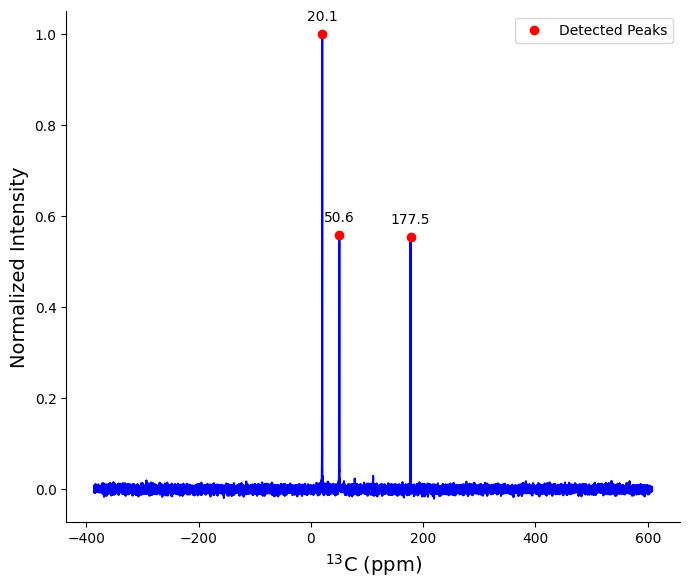

In [10]:
from scipy.signal import find_peaks

alanine = collection["Alanine"]

ppm = alanine.spectrum["ppm_scale"]
data = alanine.spectrum["norm_max"]

# Find peaks
peaks, _ = find_peaks(data, height=0.1, distance=50)
peak_ppm = ppm[peaks]
peak_heights = data[peaks]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(ppm, data, 'b-', linewidth=1.5)
ax.plot(peak_ppm, peak_heights, 'ro', label='Detected Peaks')

for i, (x, y) in enumerate(zip(peak_ppm, peak_heights)):
    ax.annotate(f'{x:.1f}', xy=(x, y), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=10)

ax.set_xlabel('$^{13}$C (ppm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()